In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
import joblib

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(
    "cleaned_data.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,December,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,December,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,December,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,December,Tuesday,7


In [3]:
print(df.shape)

print("Customers :", df["Customer ID"].nunique())

print("Products :", df["StockCode"].nunique())

(779425, 13)
Customers : 5878
Products : 4631


In [4]:
user_item = pd.pivot_table(
    df,
    index="Customer ID",
    columns="StockCode",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

user_item.head()

StockCode,10002,10080,10109,10120,10123C,10123G,10124A,10124G,10125,10133,...,BANK CHARGES,C2,D,DOT,M,PADS,POST,SP1002,TEST001,TEST002
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,45,1
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,10,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [5]:
print(user_item.shape)

(5878, 4631)


In [6]:
similarity = cosine_similarity(user_item)

similarity_df = pd.DataFrame(
    similarity,
    index=user_item.index,
    columns=user_item.index
)

similarity_df.head()

Customer ID,12346.0,12347.0,12348.0,12349.0,12350.0,12351.0,12352.0,12353.0,12354.0,12355.0,...,18278.0,18279.0,18280.0,18281.0,18282.0,18283.0,18284.0,18285.0,18286.0,18287.0
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346.0,1.000000,0.000000,0.000000,0.000003,0.000000,0.000000,2.554410e-07,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,8.762816e-07,0.000000
12347.0,0.000000,1.000000,0.158534,0.011028,0.013398,0.042812,2.250879e-02,0.028888,0.021791,0.408637,...,0.014974,0.0,0.017170,0.033951,0.012001,0.096649,0.029073,0.0,3.445478e-02,0.069793
12348.0,0.000000,0.158534,1.000000,0.000220,0.000309,0.000000,1.043401e-03,0.000000,0.011747,0.208666,...,0.000000,0.0,0.000000,0.000000,0.000000,0.158783,0.000000,0.0,0.000000e+00,0.062229
12349.0,0.000003,0.011028,0.000220,1.000000,0.026632,0.011050,1.474903e-01,0.230884,0.004490,0.020046,...,0.017185,0.0,0.001206,0.004294,0.005903,0.099257,0.096031,0.0,4.629901e-02,0.044708
12350.0,0.000000,0.013398,0.000309,0.026632,1.000000,0.000000,1.305029e-03,0.060057,0.000000,0.000000,...,0.000000,0.0,0.000000,0.072598,0.000000,0.023042,0.000000,0.0,3.069845e-02,0.000000


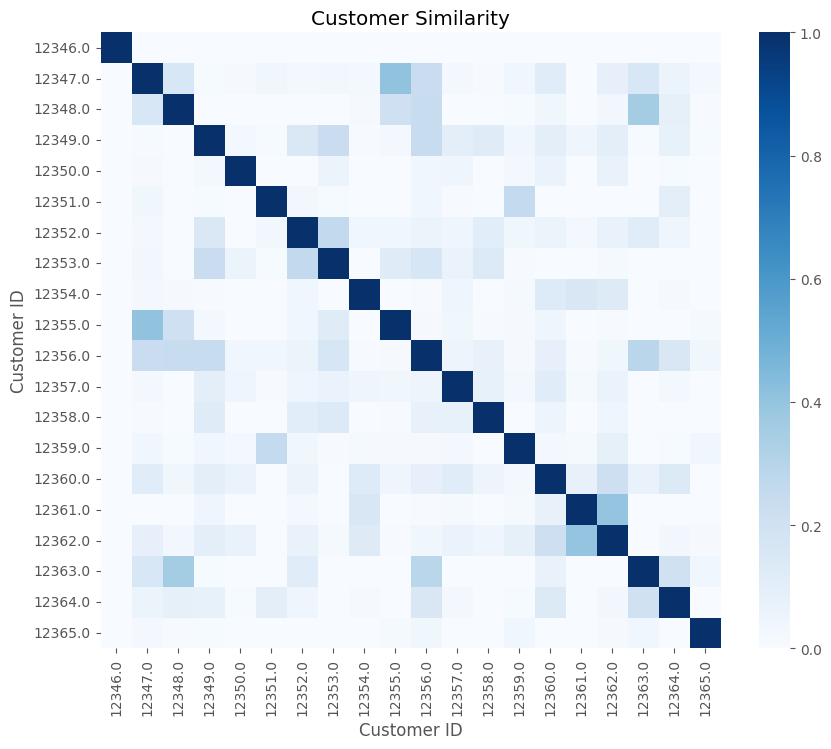

In [7]:
sample = similarity_df.iloc[:20, :20]

plt.figure(figsize=(10,8))

sns.heatmap(
    sample,
    cmap="Blues"
)

plt.title("Customer Similarity")

plt.show()

In [8]:
def recommend_products(customer_id, top_n=5):

    if customer_id not in similarity_df.index:
        return []

    similar_users = (
        similarity_df[customer_id]
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
    )

    customer_products = set(
        user_item.loc[customer_id]
        [user_item.loc[customer_id] > 0]
        .index
    )

    recommendations = {}

    for user in similar_users:

        products = user_item.loc[user]

        for product in products[products > 0].index:

            if product not in customer_products:

                recommendations[product] = recommendations.get(product, 0) + 1

    recommended = (
        sorted(
            recommendations.items(),
            key=lambda x: x[1],
            reverse=True
        )
    )

    return [x[0] for x in recommended[:top_n]]

In [9]:
customer = user_item.index[0]

recommend_products(customer)

['22720', '23165', '23167', '22722', '85048']

In [10]:
product_lookup = (
    df[
        ["StockCode", "Description"]
    ]
    .drop_duplicates()
)

In [11]:
customer = user_item.index[0]

recommended = recommend_products(customer)

recommended_products = product_lookup[
    product_lookup["StockCode"].isin(recommended)
]

recommended_products

,StockCode,Description
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS
347751,22722,SET OF 6 SPICE TINS PANTRY DESIGN
404642,22720,SET OF 3 CAKE TINS PANTRY DESIGN
512327,23167,SMALL CERAMIC TOP STORAGE JAR
512964,23165,LARGE CERAMIC TOP STORAGE JAR


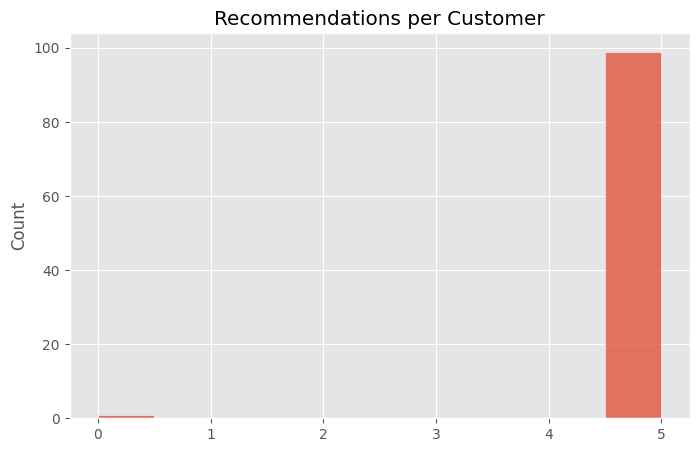

In [12]:
recommendation_list = []

for customer in user_item.index[:100]:

    rec = recommend_products(customer)

    recommendation_list.append(len(rec))

plt.figure(figsize=(8,5))

sns.histplot(
    recommendation_list,
    bins=10
)

plt.title("Recommendations per Customer")

plt.show()

In [13]:
all_rec = []

for customer in user_item.index[:500]:

    rec = recommend_products(customer)

    all_rec.extend(rec)

top_recommended = (
    pd.Series(all_rec)
      .value_counts()
      .head(10)
)

top_recommended

20725    37
21080    35
22423    26
20750    26
20726    25
22138    24
20724    23
20728    23
21034    19
21791    19
Name: count, dtype: int64

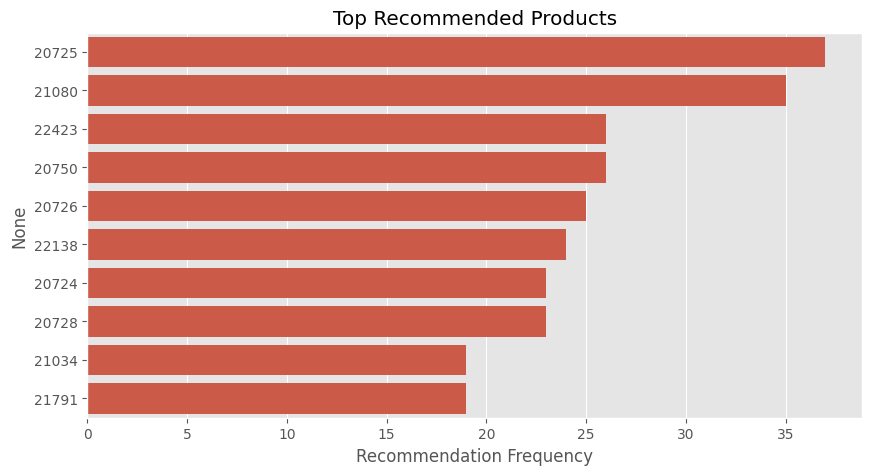

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_recommended.values,
    y=top_recommended.index.astype(str)
)

plt.title("Top Recommended Products")

plt.xlabel("Recommendation Frequency")

plt.show()

In [15]:
joblib.dump(
    similarity_df,
    "customer_similarity.pkl"
)

print("Similarity Matrix Saved")

Similarity Matrix Saved


In [16]:
user_item.to_csv(
    "user_item_matrix.csv"
)

print("User Item Matrix Saved")

User Item Matrix Saved


In [17]:
customer = user_item.index[10]

print("Customer :", customer)

recommend_products(customer)

Customer : 12356.0


['47591D', '21977', '21232', '37446', '37449']

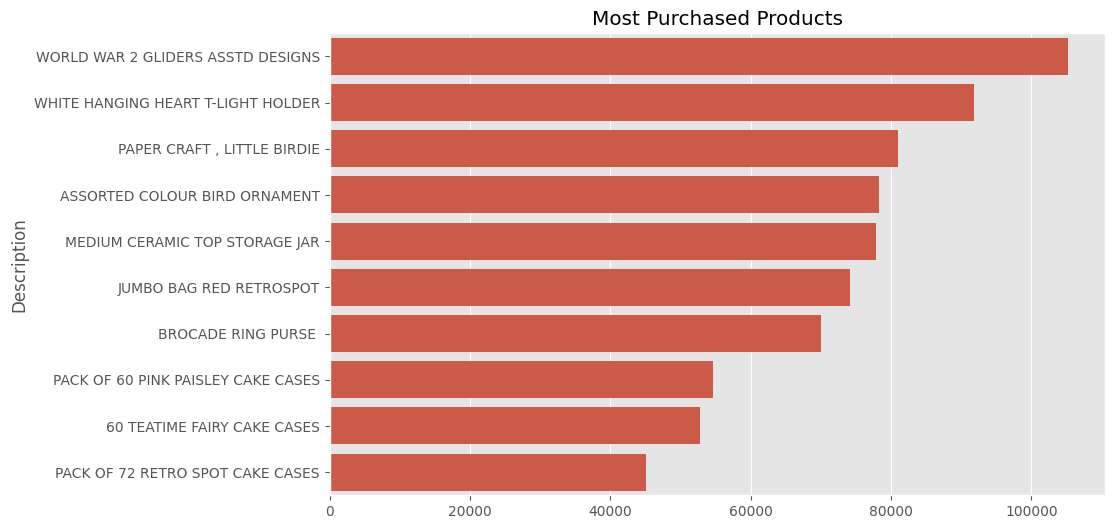

In [18]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Most Purchased Products")

plt.show()

In [19]:
print("="*60)

print("RECOMMENDATION ENGINE INSIGHTS")

print("="*60)

print("• Recommend products purchased by similar customers.")

print("• Cross-sell frequently co-purchased products.")

print("• Personalize product recommendations.")

print("• Increase customer engagement through relevant suggestions.")

print("• Improve repeat purchase rate with personalized offers.")

RECOMMENDATION ENGINE INSIGHTS
• Recommend products purchased by similar customers.
• Cross-sell frequently co-purchased products.
• Personalize product recommendations.
• Increase customer engagement through relevant suggestions.
• Improve repeat purchase rate with personalized offers.


In [20]:
print("="*60)

print("FILES GENERATED")

print("="*60)

print("customer_similarity.pkl")

print("user_item_matrix.csv")

FILES GENERATED
customer_similarity.pkl
user_item_matrix.csv
